In [1]:
%load_ext autoreload
%autoreload 2

# export pre annotations

Single image first

In [2]:
from mtrain.seg.elevated_vegetation import cached_predict, Label, get_mask_with_labels
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import cv2
import random


In [3]:
IMAGE = Path("/Users/hariomnarang/Downloads/14314.jpg")
IMAGE = Path(
    "/Users/hariomnarang/Desktop/personal/roads/mapillary_downloader/data/samples/bangalore/images/1001713403699561.jpg"
)

In [4]:
pred = cached_predict(IMAGE)
mask = get_mask_with_labels(pred, [Label.ELEVATED_VEGETATION])

/Users/hariomnarang/Desktop/personal/roads/mtrain/.venv/lib/python3.12/site-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


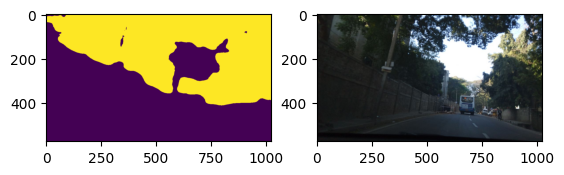

In [5]:
_,ax = plt.subplots(1, 2)
ax[0].imshow(mask)
ax[1].imshow(plt.imread(IMAGE))

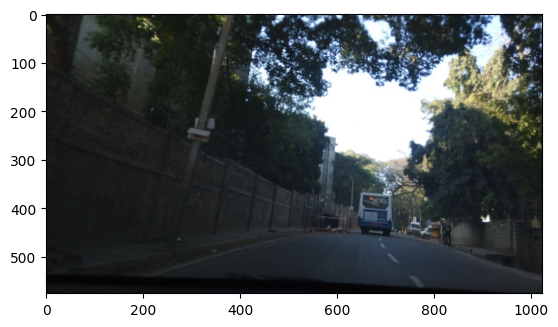

In [6]:
plt.imshow(plt.imread(IMAGE))

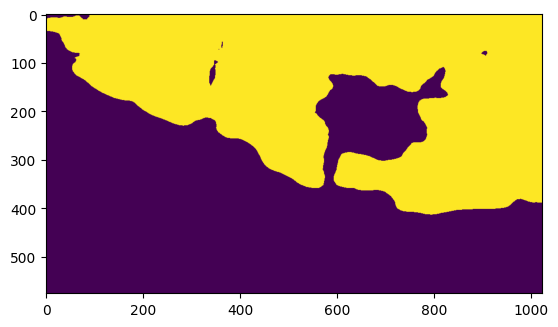

In [7]:
plt.imshow(mask)

In [8]:
from uuid import uuid4
from PIL import Image
from label_studio_converter import brush


def split_connected_components(mask, min_area=200):
    # mask: binary (0/1)
    mask = (mask > 0).astype(np.uint8)
    num, labels = cv2.connectedComponents(mask)
    components = []
    for i in range(1, num):
        comp = (labels == i).astype(np.uint8)
        if comp.sum() >= min_area:
            components.append(comp)
    return components


# make a single annotation only right now (we do clusters later if needed)

def _make_json_part(image_path, masks, label, tmp):
    anns = []
    for mask in masks:
        dest = tmp / f"{uuid4()}.png"
        Image.fromarray(mask.astype(bool)).save(dest)
        ann = brush.image2annotation(
            dest, label, "brush", "image", model_version="v1", score=0.9
        )
        anns.append(ann["result"][0])
    path = str(Path(image_path).resolve())[1:]
    return {
        # "predictions": anns,
        "predictions": [
            {
                "model_version": "v1",
                "score": 0.88,
                "result": anns,
            }
        ],
        "data": {
            "image": f"/data/local-files/?d={path}",
        },
    }


def make_json_part(image_path, label, tmp):
    pred = cached_predict(image_path)
    mask = get_mask_with_labels(pred, [Label.ELEVATED_VEGETATION])
    masks = split_connected_components(mask)
    return _make_json_part(image_path, masks, label, tmp)

In [9]:
BASE = Path("../../datasets/samples_mapillary/")
images = list(BASE.rglob("*.jpg"))


random.shuffle(images)

images = images[:300]
images[:5]

[PosixPath('../../datasets/samples_mapillary/chandni_chowk/images/737807906889907.jpg'),
 PosixPath('../../datasets/samples_mapillary/chandni_chowk/images/1836454283476732.jpg'),
 PosixPath('../../datasets/samples_mapillary/chandni_chowk/images/1152556231911078.jpg'),
 PosixPath('../../datasets/samples_mapillary/gangtok/images/1882177762569558.jpg'),
 PosixPath('../../datasets/samples_mapillary/halasuru/images/289677406132543.jpg')]

In [12]:
import tempfile
from tqdm import tqdm

with tempfile.TemporaryDirectory() as tmp:
    tmp = Path(tmp)
    # res = [make_json_part(IMAGE, tmp)]
    res = [make_json_part(im, "elevated_vegetation", tmp) for im in tqdm(images)]

100%|██████████| 300/300 [02:09<00:00,  2.31it/s]


In [13]:
import json

with open("./anns.json", "w") as f:
    json.dump(res, f)

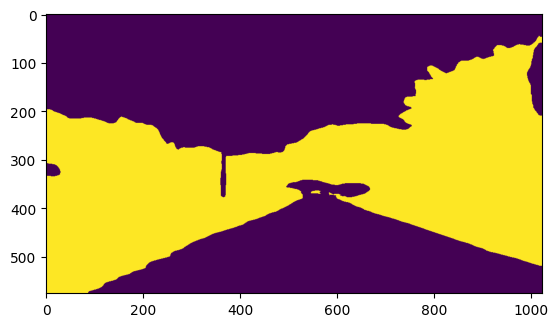

In [71]:
plt.imshow(mask)

In [72]:
from dataclasses import dataclass
from mtrain.label_studio.json_export import get_image_path
import cv2
import numpy as np


class _InputStream:
    def __init__(self, data):
        self.data = data
        self.i = 0

    def read(self, size):
        out = self.data[self.i : self.i + size]
        self.i += size
        return int(out, 2)


def _access_bit(data, num):
    """from bytes array to bits by num position"""
    base = int(num // 8)
    shift = 7 - int(num % 8)
    return (data[base] & (1 << shift)) >> shift


def _bytes2bit(data):
    """get bit string from bytes data"""
    return "".join([str(_access_bit(data, i)) for i in range(len(data) * 8)])


def _rle_to_mask(rle: list[int], height: int, width: int) -> np.array:
    """
    Converts rle to image mask
    Args:
        rle: your long rle
        height: original_height
        width: original_width

    Returns: np.array
    """

    rle_input = _InputStream(_bytes2bit(rle))

    num = rle_input.read(32)
    word_size = rle_input.read(5) + 1
    rle_sizes = [rle_input.read(4) + 1 for _ in range(4)]
    # print('RLE params:', num, 'values,', word_size, 'word_size,', rle_sizes, 'rle_sizes')

    i = 0
    out = np.zeros(num, dtype=np.uint8)
    while i < num:
        x = rle_input.read(1)
        j = i + 1 + rle_input.read(rle_sizes[rle_input.read(2)])
        if x:
            val = rle_input.read(word_size)
            out[i:j] = val
            i = j
        else:
            while i < j:
                val = rle_input.read(word_size)
                out[i] = val
                i += 1

    image = np.reshape(out, [height, width, 4])[:, :, 3]
    return image


In [73]:
rle = brush.mask2rle(mask)

In [58]:
ms = _rle_to_mask(rle, mask.shape[0], mask.shape[1])

# Test: Load RLE and make segformer ds

In [14]:
with open(
    "/Users/hariomnarang/Downloads/project-9-at-2026-02-06-11-29-481c2ec9.json"
) as f:
    import json

    content = json.load(f)

In [16]:
def keep_cont(cont):
    anns = [ann for ann in cont["annotations"] if ann["result"]]
    return len(anns) > 0

In [17]:
conts = [c for c in content if keep_cont(c)]

In [23]:
conts[0]["annotations"][0].keys()

dict_keys(['id', 'completed_by', 'result', 'was_cancelled', 'ground_truth', 'created_at', 'updated_at', 'draft_created_at', 'lead_time', 'prediction', 'result_count', 'unique_id', 'import_id', 'last_action', 'bulk_created', 'task', 'project', 'updated_by', 'parent_prediction', 'parent_annotation', 'last_created_by'])

In [24]:
from mtrain.label_studio.crops.extract import rle_to_mask

In [3]:
RLE = [
    0,
    48,
    0,
    0,
    57,
    27,
    255,
    6,
    207,
    0,
    141,
    2,
    60,
    238,
    3,
    215,
    255,
    28,
    245,
    240,
    8,
    196,
    163,
    34,
    201,
    100,
    209,
    154,
    70,
    95,
    25,
    158,
    207,
    76,
    141,
    106,
    57,
    232,
    248,
    120,
    47,
    95,
    255,
    6,
    203,
    0,
    142,
    99,
    128,
    249,
    255,
    199,
    247,
    27,
    172,
    115,
    177,
    230,
    71,
    233,
    193,
    201,
    255,
    248,
    53,
    248,
    4,
    100,
    177,
    204,
    71,
    233,
    194,
    76,
    255,
    248,
    53,
    24,
    4,
    99,
    49,
    164,
    198,
    221,
    28,
    52,
    114,
    124,
    37,
    31,
    255,
    131,
    75,
    128,
    70,
    111,
    28,
    92,
    122,
    156,
    37,
    111,
    255,
    131,
    71,
    128,
    70,
    171,
    30,
    23,
    9,
    103,
    255,
    224,
    208,
    224,
    17,
    156,
    199,
    123,
    194,
    91,
    255,
    248,
    52,
    24,
    4,
    111,
    156,
    37,
    223,
    255,
    131,
    61,
    128,
    70,
    45,
    29,
    127,
    9,
    123,
    255,
    224,
    206,
    224,
    17,
    190,
    71,
    197,
    194,
    95,
    255,
    248,
    51,
    152,
    4,
    114,
    60,
    38,
    31,
    255,
    131,
    53,
    128,
    70,
    137,
    30,
    151,
    9,
    139,
    255,
    224,
    204,
    224,
    17,
    197,
    240,
    153,
    63,
    254,
    12,
    190,
    1,
    25,
    212,
    122,
    28,
    38,
    95,
    255,
    131,
    45,
    128,
    70,
    221,
    194,
    103,
    255,
    248,
    50,
    152,
    4,
    97,
    17,
    208,
    240,
    154,
    63,
    254,
    12,
    158,
    1,
    25,
    220,
    122,
    156,
    38,
    159,
    255,
    131,
    37,
    128,
    70,
    221,
    194,
    107,
    255,
    248,
    50,
    24,
    4,
    97,
    209,
    253,
    112,
    155,
    63,
    254,
    12,
    126,
    1,
    26,
    84,
    123,
    188,
    38,
    223,
    255,
    131,
    29,
    128,
    71,
    19,
    194,
    111,
    255,
    248,
    49,
    152,
    4,
    102,
    177,
    228,
    112,
    156,
    63,
    254,
    12,
    94,
    1,
    27,
    167,
    9,
    203,
    255,
    224,
    196,
    224,
    17,
    144,
    71,
    103,
    194,
    115,
    255,
    248,
    49,
    24,
    4,
    107,
    209,
    248,
    240,
    157,
    63,
    254,
    12,
    62,
    1,
    28,
    87,
    9,
    219,
    255,
    224,
    194,
    224,
    17,
    138,
    71,
    103,
    194,
    32,
    255,
    227,
    246,
    143,
    146,
    61,
    24,
    239,
    227,
    172,
    142,
    106,
    56,
    120,
    241,
    99,
    141,
    141,
    251,
    128,
    153,
    255,
    240,
    97,
    48,
    8,
    206,
    227,
    219,
    225,
    9,
    255,
    241,
    255,
    71,
    241,
    31,
    148,
    125,
    145,
    243,
    199,
    195,
    30,
    220,
    122,
    209,
    232,
    71,
    149,
    30,
    36,
    119,
    241,
    217,
    199,
    53,
    27,
    188,
    105,
    145,
    139,
    97,
    112,
    8,
    214,
    120,
    9,
    159,
    255,
    6,
    11,
    0,
    140,
    38,
    57,
    94,
    17,
    55,
    255,
    30,
    76,
    111,
    81,
    144,
    91,
    0,
    140,
    163,
    128,
    153,
    255,
    240,
    96,
    48,
    8,
    193,
    227,
    124,
    143,
    171,
    132,
    85,
    255,
    199,
    71,
    25,
    140,
    96,
    49,
    162,
    71,
    197,
    192,
    75,
    255,
    248,
    47,
    248,
    4,
    108,
    49,
    242,
    240,
    159,
    127,
    254,
    11,
    238,
    1,
    24,
    100,
    116,
    220,
    39,
    255,
    255,
    130,
    249,
    128,
    70,
    89,
    30,
    151,
    10,
    3,
    255,
    224,
    189,
    224,
    17,
    154,
    71,
    207,
    194,
    129,
    255,
    248,
    47,
    88,
    4,
    100,
    145,
    241,
    240,
    160,
    191,
    254,
    11,
    206,
    1,
    25,
    20,
    120,
    252,
    40,
    63,
    255,
    130,
    241,
    128,
    70,
    105,
    31,
    23,
    10,
    19,
    255,
    224,
    187,
    224,
    17,
    151,
    71,
    209,
    194,
    133,
    255,
    248,
    46,
    216,
    4,
    98,
    145,
    235,
    112,
    161,
    191,
    254,
    11,
    182,
    1,
    29,
    215,
    10,
    31,
    255,
    224,
    186,
    224,
    17,
    210,
    112,
    162,
    63,
    254,
    11,
    166,
    1,
    30,
    55,
    10,
    39,
    255,
    224,
    185,
    224,
    17,
    238,
    240,
    162,
    191,
    254,
    11,
    142,
    1,
    24,
    132,
    126,
    156,
    40,
    191,
    255,
    130,
    225,
    128,
    70,
    135,
    30,
    231,
    10,
    51,
    255,
    224,
    183,
    224,
    17,
    187,
    112,
    163,
    191,
    254,
    11,
    110,
    1,
    24,
    60,
    117,
    28,
    40,
    255,
    255,
    130,
    217,
    128,
    70,
    51,
    30,
    63,
    10,
    67,
    255,
    224,
    181,
    224,
    17,
    138,
    71,
    157,
    194,
    145,
    255,
    248,
    45,
    120,
    4,
    119,
    156,
    41,
    47,
    255,
    130,
    213,
    128,
    71,
    75,
    194,
    147,
    255,
    248,
    45,
    56,
    4,
    113,
    188,
    41,
    79,
    255,
    130,
    209,
    128,
    70,
    235,
    194,
    149,
    255,
    248,
    44,
    248,
    4,
    112,
    156,
    41,
    111,
    255,
    130,
    205,
    128,
    71,
    41,
    194,
    151,
    255,
    248,
    44,
    184,
    4,
    115,
    92,
    41,
    143,
    255,
    130,
    201,
    128,
    71,
    63,
    194,
    153,
    255,
    248,
    44,
    88,
    4,
    98,
    241,
    225,
    112,
    166,
    191,
    254,
    11,
    14,
    1,
    24,
    212,
    121,
    220,
    41,
    191,
    255,
    130,
    193,
    128,
    70,
    53,
    30,
    119,
    5,
    155,
    255,
    143,
    238,
    60,
    120,
    240,
    248,
    38,
    95,
    255,
    5,
    127,
    0,
    140,
    106,
    60,
    238,
    11,
    71,
    255,
    30,
    140,
    126,
    220,
    19,
    47,
    255,
    130,
    189,
    128,
    70,
    53,
    30,
    103,
    10,
    123,
    255,
    224,
    174,
    224,
    17,
    134,
    199,
    149,
    194,
    159,
    255,
    248,
    43,
    184,
    4,
    118,
    60,
    42,
    15,
    255,
    130,
    185,
    128,
    70,
    255,
    194,
    161,
    255,
    248,
    43,
    120,
    4,
    102,
    220,
    42,
    47,
    255,
    130,
    183,
    128,
    71,
    111,
    194,
    162,
    255,
    248,
    43,
    88,
    4,
    105,
    92,
    42,
    63,
    255,
    130,
    181,
    128,
    71,
    103,
    194,
    163,
    255,
    248,
    43,
    56,
    4,
    100,
    92,
    42,
    79,
    255,
    130,
    179,
    128,
    70,
    231,
    194,
    164,
    255,
    248,
    43,
    56,
    4,
    119,
    28,
    42,
    79,
    255,
    130,
    179,
    128,
    71,
    231,
    194,
    164,
    255,
    248,
    43,
    24,
    4,
    100,
    188,
    42,
    95,
    255,
    130,
    177,
    128,
    70,
    141,
    194,
    165,
    255,
    248,
    43,
    24,
    4,
    107,
    156,
    42,
    95,
    255,
    130,
    177,
    128,
    70,
    203,
    194,
    165,
    255,
    248,
    43,
    24,
    4,
    108,
    220,
    42,
    95,
    255,
    130,
    177,
    128,
    70,
    205,
    194,
    165,
    255,
    248,
    43,
    24,
    4,
    108,
    220,
    42,
    95,
    255,
    130,
    177,
    128,
    70,
    203,
    194,
    165,
    255,
    248,
    43,
    24,
    4,
    107,
    156,
    42,
    95,
    255,
    130,
    177,
    128,
    70,
    143,
    194,
    165,
    255,
    248,
    43,
    24,
    4,
    100,
    220,
    42,
    95,
    255,
    130,
    179,
    128,
    71,
    241,
    194,
    164,
    255,
    248,
    43,
    56,
    4,
    121,
    220,
    42,
    79,
    255,
    130,
    179,
    128,
    71,
    73,
    194,
    164,
    255,
    248,
    43,
    56,
    4,
    111,
    92,
    42,
    79,
    255,
    130,
    179,
    128,
    70,
    161,
    194,
    164,
    255,
    248,
    43,
    56,
    4,
    100,
    156,
    42,
    79,
    255,
    130,
    181,
    128,
    71,
    203,
    194,
    163,
    255,
    248,
    43,
    88,
    4,
    117,
    92,
    42,
    63,
    255,
    130,
    181,
    128,
    71,
    47,
    194,
    163,
    255,
    248,
    43,
    88,
    4,
    111,
    60,
    42,
    63,
    255,
    130,
    181,
    128,
    70,
    157,
    194,
    163,
    255,
    248,
    43,
    88,
    4,
    99,
    60,
    42,
    63,
    255,
    130,
    183,
    128,
    71,
    155,
    194,
    162,
    255,
    248,
    43,
    120,
    4,
    111,
    220,
    42,
    47,
    255,
    130,
    183,
    128,
    70,
    75,
    194,
    162,
    255,
    248,
    43,
    152,
    4,
    117,
    60,
    42,
    31,
    255,
    130,
    185,
    128,
    70,
    111,
    194,
    161,
    255,
    248,
    43,
    184,
    4,
    114,
    252,
    17,
    127,
    254,
    62,
    72,
    254,
    248,
    48,
    223,
    255,
    5,
    119,
    0,
    140,
    58,
    62,
    30,
    8,
    151,
    255,
    31,
    92,
    119,
    17,
    188,
    198,
    97,
    24,
    4,
    98,
    17,
    197,
    240,
    97,
    127,
    254,
    10,
    246,
    1,
    26,
    87,
    4,
    27,
    255,
    143,
    170,
    60,
    24,
    227,
    163,
    78,
    190,
    131,
    26,
    4,
    103,
    209,
    151,
    198,
    43,
    134,
    192,
    35,
    82,
    224,
    194,
    127,
    252,
    21,
    252,
    2,
    57,
    206,
    7,
    127,
    255,
    30,
    44,
    108,
    241,
    148,
    100,
    49,
    184,
    197,
    227,
    8,
    201,
    224,
    17,
    162,
    199,
    245,
    193,
    130,
    255,
    248,
    43,
    248,
    4,
    97,
    209,
    238,
    240,
    59,
    127,
    248,
    231,
    117,
    88,
    4,
    104,
    177,
    254,
    112,
    96,
    127,
    254,
    11,
    6,
    1,
    26,
    111,
    3,
    179,
    255,
    142,
    223,
    89,
    128,
    70,
    139,
    31,
    247,
    6,
    3,
    255,
    224,
    176,
    224,
    17,
    206,
    112,
    58,
    191,
    248,
    238,
    227,
    6,
    214,
    224,
    17,
    176,
    240,
    96,
    63,
    254,
    11,
    14,
    1,
    24,
    76,
    122,
    156,
    14,
    143,
    254,
    59,
    184,
    193,
    245,
    248,
    4,
    110,
    188,
    23,
    255,
    255,
    130,
    197,
    128,
    70,
    103,
    31,
    167,
    3,
    155,
    255,
    142,
    238,
    48,
    125,
    142,
    1,
    27,
    172,
    127,
    220,
    23,
    223,
    255,
    130,
    199,
    128,
    70,
    143,
    31,
    231,
    3,
    147,
    255,
    142,
    238,
    48,
    125,
    158,
    1,
    26,
    164,
    126,
    220,
    23,
    207,
    255,
    130,
    201,
    128,
    70,
    133,
    31,
    95,
    3,
    139,
    255,
    142,
    190,
    48,
    77,
    174,
    1,
    24,
    36,
    122,
    220,
    23,
    191,
    255,
    130,
    203,
    128,
    70,
    77,
    31,
    87,
    3,
    131,
    255,
    142,
    143,
    115,
    128,
    71,
    35,
    193,
    122,
    255,
    248,
    44,
    216,
    4,
    104,
    49,
    253,
    240,
    55,
    191,
    248,
    238,
    119,
    120,
    4,
    102,
    177,
    238,
    112,
    94,
    63,
    254,
    11,
    62,
    1,
    26,
    60,
    126,
    188,
    13,
    207,
    254,
    59,
    168,
    193,
    247,
    184,
    4,
    113,
    92,
    23,
    127,
    255,
    130,
    209,
    128,
    70,
    107,
    30,
    231,
    3,
    107,
    255,
    142,
    210,
    48,
    109,
    254,
    1,
    26,
    36,
    122,
    60,
    23,
    95,
    255,
    130,
    211,
    128,
    70,
    23,
    30,
    223,
    3,
    99,
    255,
    143,
    135,
    128,
    135,
    128,
    71,
    21,
    193,
    116,
    255,
    248,
    45,
    88,
    4,
    103,
    28,
    13,
    143,
    254,
    51,
    238,
    2,
    38,
    1,
    28,
    71,
    5,
    207,
    255,
    224,
    181,
    224,
    28,
    13,
    127,
    254,
    60,
    126,
    2,
    54,
    1,
    24,
    151,
    5,
    203,
    255,
    141,
    190,
    56,
    40,
    226,
    35,
    131,
    141,
    202,
    53,
    88,
    203,
    56,
    44,
    152,
    4,
    107,
    124,
    13,
    111,
    254,
    54,
    238,
    2,
    70,
    1,
    31,
    79,
    5,
    223,
    255,
    143,
    194,
    58,
    232,
    216,
    99,
    10,
    224,
    176,
    96,
    17,
    130,
    71,
    227,
    192,
    213,
    255,
    227,
    20,
    224,
    36,
    224,
    17,
    215,
    112,
    94,
    127,
    248,
    253,
    163,
    144,
    140,
    131,
    130,
    191,
    128,
    71,
    25,
    192,
    212,
    255,
    227,
    169,
    224,
    37,
    224,
    17,
    212,
    240,
    94,
    255,
    248,
    224,
    248,
    43,
    216,
    4,
    99,
    188,
    13,
    79,
    254,
    52,
    254,
    2,
    102,
    1,
    28,
    95,
    5,
    239,
    255,
    143,
    66,
    51,
    190,
    10,
    238,
    1,
    28,
    15,
    3,
    75,
    255,
    143,
    151,
    128,
    157,
    128,
    70,
    173,
    31,
    31,
    5,
    239,
    255,
    141,
    143,
    130,
    187,
    128,
    71,
    161,
    192,
    209,
    255,
    227,
    133,
    224,
    39,
    224,
    17,
    133,
    71,
    19,
    193,
    123,
    255,
    227,
    176,
    140,
    27,
    130,
    183,
    128,
    70,
    121,
    192,
    209,
    255,
    227,
    27,
    224,
    40,
    224,
    17,
    141,
    112,
    95,
    63,
    248,
    211,
    120,
    43,
    120,
    4,
    108,
    188,
    12,
    255,
    254,
    56,
    126,
    2,
    166,
    1,
    26,
    255,
    5,
    239,
    255,
    142,
    79,
    130,
    183,
    128,
    70,
    239,
    192,
    205,
    255,
    227,
    225,
    140,
    23,
    128,
    171,
    128,
    70,
    59,
    29,
    167,
    5,
    235,
    255,
    143,
    46,
    50,
    174,
    10,
    214,
    1,
    28,
    247,
    3,
    51,
    255,
    141,
    191,
    128,
    177,
    128,
    71,
    25,
    193,
    122,
    255,
    227,
    234,
    140,
    247,
    130,
    179,
    128,
    70,
    29,
    30,
    231,
    3,
    47,
    255,
    224,
    45,
    96,
    17,
    178,
    112,
    94,
    191,
    248,
    252,
    163,
    56,
    224,
    172,
    224,
    17,
    159,
    240,
    50,
    191,
    248,
    223,
    120,
    11,
    120,
    4,
    103,
    145,
    235,
    112,
    94,
    127,
    248,
    248,
    99,
    28,
    224,
    172,
    224,
    17,
    173,
    112,
    50,
    127,
    248,
    222,
    120,
    11,
    152,
    4,
    97,
    92,
    23,
    175,
    254,
    60,
    14,
    10,
    206,
    1,
    28,
    63,
    3,
    43,
    255,
    142,
    27,
    128,
    187,
    128,
    71,
    223,
    193,
    121,
    255,
    227,
    159,
    224,
    171,
    224,
    17,
    145,
    240,
    51,
    63,
    248,
    223,
    56,
    11,
    184,
    4,
    113,
    156,
    23,
    159,
    254,
    55,
    254,
    10,
    182,
    1,
    28,
    151,
    3,
    55,
    255,
    141,
    107,
    128,
    187,
    128,
    70,
    255,
    193,
    121,
    255,
    227,
    94,
    224,
    170,
    96,
    17,
    133,
    71,
    241,
    192,
    205,
    255,
    227,
    242,
    140,
    131,
    128,
    187,
    128,
    70,
    233,
    193,
    121,
    255,
    227,
    62,
    224,
    169,
    224,
    17,
    176,
    240,
    51,
    255,
    248,
    234,
    184,
    11,
    216,
    4,
    106,
    81,
    245,
    112,
    93,
    255,
    248,
    247,
    99,
    22,
    224,
    169,
    96,
    17,
    214,
    240,
    52,
    63,
    248,
    211,
    56,
    11,
    216,
    4,
    99,
    17,
    209,
    112,
    93,
    255,
    248,
    237,
    120,
    42,
    88,
    4,
    125,
    220,
    13,
    15,
    254,
    59,
    254,
    3,
    6,
    1,
    26,
    36,
    127,
    60,
    23,
    111,
    254,
    62,
    46,
    10,
    134,
    1,
    25,
    79,
    3,
    75,
    255,
    140,
    247,
    128,
    195,
    128,
    71,
    7,
    193,
    118,
    255,
    227,
    222,
    140,
    23,
    130,
    157,
    128,
    70,
    163,
    192,
    210,
    255,
    227,
    152,
    224,
    49,
    96,
    17,
    133,
    71,
    71,
    193,
    118,
    255,
    227,
    218,
    142,
    154,
    54,
    120,
    199,
    120,
    41,
    88,
    4,
    109,
    188,
    13,
    47,
    254,
    62,
    142,
    3,
    38,
    1,
    27,
    76,
    126,
    124,
    23,
    143,
    254,
    59,
    104,
    212,
    248,
    41,
    24,
    4,
    111,
    188,
    13,
    63,
    254,
    51,
    110,
    3,
    38,
    1,
    24,
    204,
    115,
    188,
    23,
    175,
    254,
    58,
    136,
    196,
    184,
    40,
    184,
    4,
    112,
    60,
    13,
    63,
    254,
    54,
    222,
    3,
    54,
    1,
    26,
    44,
    121,
    28,
    23,
    175,
    254,
    60,
    120,
    222,
    163,
    33,
    224,
    161,
    96,
    17,
    192,
    240,
    52,
    255,
    248,
    230,
    56,
    13,
    24,
    4,
    110,
    17,
    249,
    112,
    94,
    255,
    248,
    233,
    227,
    54,
    224,
    160,
    96,
    17,
    188,
    112,
    52,
    255,
    248,
    238,
    56,
    13,
    56,
    4,
    98,
    81,
    211,
    112,
    95,
    127,
    248,
    214,
    248,
    39,
    216,
    4,
    108,
    92,
    13,
    63,
    254,
    60,
    190,
    3,
    94,
    1,
    24,
    255,
    5,
    251,
    255,
    142,
    230,
    55,
    200,
    205,
    56,
    39,
    88,
    4,
    104,
    60,
    13,
    63,
    254,
    61,
    62,
    3,
    110,
    1,
    27,
    143,
    5,
    255,
    255,
    143,
    70,
    54,
    248,
    194,
    248,
    38,
    248,
    4,
    98,
    188,
    13,
    79,
    255,
    128,
    221,
    128,
    70,
    111,
    30,
    15,
    6,
    3,
    255,
    143,
    18,
    51,
    110,
    8,
    126,
    1,
    24,
    196,
    103,
    145,
    176,
    71,
    7,
    28,
    228,
    117,
    17,
    212,
    228,
    186,
    168,
    233,
    163,
    151,
    141,
    238,
    53,
    72,
    200,
    176,
    248,
    4,
    122,
    156,
    13,
    47,
    254,
    61,
    62,
    3,
    134,
    1,
    27,
    28,
    122,
    220,
    24,
    47,
    254,
    60,
    168,
    217,
    35,
    64,
    140,
    115,
    130,
    7,
    128,
    70,
    43,
    26,
    140,
    112,
    49,
    211,
    199,
    153,
    31,
    134,
    135,
    255,
    143,
    62,
    60,
    88,
    236,
    35,
    143,
    141,
    174,
    58,
    222,
    6,
    151,
    255,
    30,
    159,
    1,
    203,
    0,
    141,
    146,
    61,
    110,
    12,
    39,
    255,
    31,
    164,
    121,
    241,
    213,
    198,
    247,
    25,
    255,
    3,
    239,
    0,
    140,
    194,
    55,
    152,
    240,
    184,
    32,
    31,
    252,
    122,
    124,
    7,
    76,
    2,
    54,
    72,
    245,
    184,
    48,
    255,
    252,
    126,
    17,
    212,
    198,
    199,
    24,
    247,
    3,
    211,
    0,
    141,
    110,
    59,
    8,
    246,
    248,
    32,
    127,
    252,
    122,
    124,
    7,
    108,
    2,
    54,
    72,
    245,
    248,
    49,
    63,
    252,
    121,
    177,
    195,
    70,
    125,
    192,
    230,
    192,
    35,
    15,
    140,
    222,
    53,
    40,
    217,
    227,
    124,
    142,
    74,
    58,
    120,
    239,
    56,
    33,
    63,
    252,
    122,
    124,
    7,
    140,
    2,
    54,
    72,
    245,
    184,
    49,
    95,
    252,
    123,
    113,
    190,
    198,
    61,
    192,
    223,
    192,
    35,
    29,
    141,
    110,
    57,
    152,
    245,
    184,
    34,
    63,
    252,
    122,
    124,
    7,
    172,
    2,
    54,
    88,
    245,
    248,
    49,
    127,
    252,
    117,
    145,
    166,
    240,
    54,
    112,
    8,
    199,
    99,
    91,
    142,
    102,
    61,
    126,
    8,
    175,
    255,
    30,
    111,
    1,
    243,
    0,
    141,
    146,
    61,
    126,
    12,
    111,
    255,
    31,
    166,
    159,
    214,
    143,
    94,
    62,
    24,
    250,
    163,
    240,
    143,
    214,
    127,
    136,
    253,
    227,
    244,
    143,
    190,
    62,
    136,
    248,
    48,
    254,
    180,
    122,
    177,
    234,
    71,
    143,
    29,
    116,
    113,
    49,
    172,
    70,
    57,
    192,
    142,
    192,
    35,
    11,
    140,
    234,
    59,
    168,
    250,
    35,
    215,
    224,
    140,
    255,
    241,
    221,
    112,
    31,
    176,
    8,
    217,
    99,
    215,
    224,
    231,
    255,
    241,
    237,
    199,
    115,
    28,
    92,
    106,
    81,
    138,
    112,
    32,
    240,
    8,
    194,
    227,
    53,
    141,
    126,
    56,
    152,
    236,
    227,
    221,
    224,
    143,
    127,
    241,
    205,
    240,
    32,
    48,
    8,
    217,
    35,
    214,
    224,
    233,
    127,
    241,
    230,
    199,
    31,
    26,
    124,
    96,
    124,
    7,
    172,
    2,
    50,
    120,
    213,
    99,
    131,
    142,
    194,
    61,
    222,
    9,
    39,
    255,
    27,
    143,
    2,
    11,
    0,
    141,
    146,
    61,
    126,
    14,
    159,
    255,
    31,
    172,
    115,
    113,
    182,
    70,
    195,
    26,
    92,
    101,
    60,
    6,
    252,
    2,
    49,
    8,
    207,
    163,
    108,
    142,
    102,
    60,
    120,
    253,
    120,
    37,
    63,
    252,
    103,
    124,
    8,
    76,
    2,
    54,
    72,
    245,
    184,
    58,
    255,
    252,
    126,
    209,
    221,
    198,
    251,
    25,
    252,
    96,
    60,
    6,
    108,
    2,
    49,
    184,
    214,
    99,
    151,
    143,
    87,
    130,
    93,
    255,
    199,
    221,
    24,
    47,
    2,
    27,
    0,
    141,
    114,
    59,
    206,
    14,
    207,
    255,
    31,
    204,
    119,
    113,
    190,
    198,
    127,
    24,
    15,
    1,
    119,
    0,
    140,
    74,
    53,
    216,
    233,
    163,
    213,
    143,
    199,
    130,
    103,
    255,
    198,
    241,
    192,
    136,
    192,
    35,
    32,
    142,
    79,
    131,
    183,
    255,
    199,
    239,
    29,
    124,
    107,
    209,
    134,
    240,
    21,
    240,
    8,
    203,
    163,
    163,
    143,
    155,
    130,
    113,
    255,
    199,
    193,
    192,
    138,
    192,
    35,
    77,
    143,
    63,
    131,
    187,
    255,
    199,
    229,
    30,
    100,
    112,
    113,
    159,
    70,
    53,
    24,
    15,
    1,
    27,
    0,
    140,
    50,
    50,
    9,
    202,
    99,
    45,
    141,
    58,
    54,
    200,
    217,
    35,
    168,
    224,
    159,
    127,
    241,
    167,
    112,
    34,
    240,
    8,
    217,
    35,
    206,
    224,
    240,
    255,
    241,
    236,
    199,
    79,
    27,
    84,
    101,
    219,
    76,
    2,
    48,
    168,
    203,
    35,
    67,
    141,
    58,
    250,
    124,
    108,
    209,
    200,
    71,
    117,
    30,
    28,
    119,
    241,
    244,
    240,
    81,
    255,
    248,
    231,
    184,
    17,
    184,
    4,
    104,
    17,
    201,
    71,
    177,
    193,
    226,
    255,
    227,
    231,
    142,
    170,
    54,
    104,
    197,
    245,
    152,
    4,
    96,
    113,
    170,
    199,
    55,
    30,
    183,
    5,
    87,
    255,
    143,
    139,
    129,
    33,
    128,
    70,
    225,
    31,
    63,
    7,
    155,
    255,
    142,
    195,
    79,
    204,
    199,
    159,
    31,
    252,
    126,
    92,
    21,
    159,
    254,
    50,
    46,
    4,
    134,
    1,
    24,
    20,
    109,
    81,
    228,
    112,
    218,
    191,
    248,
    211,
    120,
    18,
    120,
    4,
    103,
    209,
    228,
    199,
    233,
    195,
    103,
    255,
    227,
    108,
    224,
    74,
    224,
    17,
    133,
    70,
    213,
    29,
    255,
    13,
    151,
    255,
    142,
    3,
    129,
    49,
    128,
    70,
    41,
    28,
    119,
    13,
    143,
    255,
    142,
    35,
    129,
    53,
    128,
    70,
    75,
    28,
    223,
    13,
    135,
    255,
    142,
    35,
    129,
    57,
    128,
    70,
    189,
    31,
    63,
    13,
    127,
    255,
    142,
    39,
    129,
    59,
    128,
    70,
    23,
    28,
    44,
    126,
    220,
    53,
    223,
    254,
    56,
    142,
    4,
    254,
    1,
    24,
    116,
    110,
    49,
    228,
    240,
    214,
    255,
    248,
    226,
    56,
    20,
    88,
    4,
    100,
    81,
    176,
    199,
    43,
    195,
    88,
    255,
    227,
    136,
    224,
    83,
    96,
    17,
    186,
    112,
    213,
    191,
    248,
    225,
    120,
    20,
    248,
    4,
    100,
    209,
    210,
    112,
    213,
    63,
    248,
    221,
    248,
    21,
    56,
    4,
    102,
    113,
    204,
    199,
    235,
    195,
    81,
    255,
    227,
    93,
    224,
    85,
    224,
    17,
    130,
    70,
    165,
    28,
    164,
    121,
    156,
    52,
    239,
    254,
    51,
    126,
    5,
    134,
    1,
    25,
    108,
    114,
    209,
    243,
    240,
    64,
    127,
    248,
    253,
    248,
    72,
    223,
    252,
    127,
    209,
    130,
    240,
    44,
    240,
    8,
    215,
    99,
    178,
    224,
    127,
    255,
    241,
    241,
    240,
    145,
    191,
    248,
    239,
    184,
    22,
    216,
    4,
    98,
    17,
    176,
    199,
    129,
    192,
    252,
    255,
    227,
    194,
    225,
    35,
    127,
    241,
    186,
    112,
    46,
    112,
    8,
    200,
    99,
    161,
    143,
    103,
    129,
    243,
    255,
    199,
    45,
    194,
    70,
    255,
    227,
    30,
    224,
    94,
    96,
    17,
    169,
    199,
    113,
    192,
    247,
    255,
    227,
    95,
    225,
    34,
    255,
    241,
    212,
    112,
    47,
    240,
    8,
    204,
    163,
    150,
    143,
    239,
    129,
    233,
    255,
    198,
    67,
    194,
    69,
    255,
    227,
    58,
    224,
    96,
    224,
    17,
    136,
    70,
    235,
    30,
    207,
    3,
    199,
    255,
    143,
    110,
    48,
    14,
    18,
    39,
    255,
    29,
    103,
    3,
    23,
    0,
    141,
    78,
    59,
    126,
    7,
    127,
    255,
    28,
    228,
    96,
    28,
    36,
    79,
    254,
    51,
    158,
    6,
    62,
    1,
    25,
    108,
    112,
    81,
    230,
    240,
    59,
    63,
    248,
    215,
    163,
    0,
    225,
    33,
    255,
    241,
    214,
    112,
    50,
    240,
    8,
    197,
    99,
    83,
    142,
    147,
    129,
    211,
    255,
    198,
    41,
    24,
    7,
    9,
    15,
    255,
    140,
    223,
    129,
    159,
    128,
    70,
    95,
    30,
    255,
    3,
    151,
    255,
    142,
    186,
    112,
    14,
    18,
    23,
    255,
    28,
    159,
    3,
    75,
    0,
    140,
    106,
    56,
    200,
    255,
    184,
    28,
    95,
    252,
    105,
    115,
    128,
    112,
    144,
    127,
    248,
    246,
    35,
    7,
    224,
    106,
    96,
    17,
    141,
    71,
    25,
    31,
    191,
    3,
    127,
    255,
    143,
    10,
    216,
    7,
    9,
    7,
    255,
    140,
    255,
    129,
    175,
    128,
    70,
    25,
    27,
    76,
    120,
    92,
    13,
    223,
    254,
    52,
    139,
    96,
    28,
    36,
    15,
    254,
    53,
    254,
    6,
    222,
    1,
    25,
    108,
    112,
    209,
    240,
    112,
    54,
    127,
    248,
    230,
    239,
    128,
    112,
    143,
    255,
    248,
    217,
    248,
    27,
    248,
    4,
    105,
    113,
    210,
    71,
    253,
    192,
    213,
    255,
    227,
    225,
    140,
    54,
    248,
    7,
    8,
    251,
    255,
    142,
    183,
    129,
    197,
    128,
    70,
    29,
    26,
    228,
    116,
    209,
    247,
    240,
    52,
    191,
    248,
    213,
    48,
    152,
    7,
    8,
    247,
    255,
    143,
    123,
    129,
    207,
    128,
    70,
    137,
    28,
    108,
    122,
    252,
    12,
    239,
    254,
    57,
    156,
    46,
    1,
    194,
    60,
    255,
    227,
    159,
    224,
    117,
    224,
    17,
    150,
    70,
    235,
    29,
    247,
    3,
    43,
    255,
    143,
    50,
    48,
    60,
    46,
    1,
    194,
    59,
    255,
    227,
    199,
    224,
    119,
    224,
    17,
    136,
    198,
    159,
    28,
    12,
    116,
    241,
    225,
    71,
    185,
    31,
    175,
    3,
    11,
    255,
    143,
    158,
    50,
    140,
    54,
    1,
    194,
    58,
    255,
    227,
    237,
    140,
    163,
    129,
    237,
    128,
    70,
    33,
    25,
    84,
    106,
    177,
    220,
    112,
    47,
    127,
    248,
    250,
    227,
    55,
    195,
    224,
    28,
    35,
    175,
    254,
    52,
    94,
    7,
    238,
    1,
    26,
    20,
    113,
    113,
    234,
    240,
    45,
    255,
    248,
    250,
    163,
    55,
    196,
    96,
    28,
    35,
    143,
    254,
    63,
    168,
    210,
    248,
    32,
    56,
    4,
    101,
    49,
    185,
    71,
    99,
    31,
    47,
    2,
    203,
    255,
    143,
    150,
    51,
    108,
    78,
    1,
    194,
    55,
    255,
    227,
    227,
    140,
    235,
    130,
    13,
    128,
    70,
    33,
    25,
    84,
    104,
    81,
    172,
    198,
    225,
    28,
    68,
    115,
    241,
    219,
    71,
    177,
    31,
    148,
    127,
    220,
    10,
    111,
    254,
    60,
    136,
    201,
    177,
    88,
    7,
    8,
    219,
    255,
    143,
    46,
    50,
    62,
    8,
    150,
    1,
    25,
    172,
    111,
    241,
    225,
    240,
    40,
    191,
    248,
    229,
    49,
    152,
    7,
    8,
    215,
    255,
    142,
    206,
    48,
    190,
    8,
    182,
    1,
    24,
    164,
    107,
    241,
    212,
    199,
    227,
    192,
    156,
    255,
    227,
    199,
    141,
    35,
    27,
    128,
    112,
    141,
    63,
    248,
    230,
    248,
    35,
    152,
    4,
    102,
    113,
    176,
    199,
    9,
    28,
    252,
    119,
    81,
    234,
    71,
    223,
    192,
    114,
    255,
    227,
    251,
    142,
    130,
    58,
    60,
    71,
    77,
    30,
    230,
    79,
    255,
    142,
    246,
    53,
    108,
    126,
    1,
    194,
    51,
    255,
    227,
    131,
    224,
    146,
    96,
    17,
    134,
    70,
    79,
    26,
    20,
    107,
    145,
    187,
    199,
    37,
    29,
    100,
    120,
    241,
    241,
    71,
    251,
    192,
    104,
    255,
    227,
    109,
    197,
    224,
    17,
    162,
    71,
    31,
    30,
    118,
    51,
    255,
    143,
    206,
    59,
    184,
    222,
    35,
    42,
    200,
    224,
    28,
    35,
    47,
    254,
    54,
    190,
    9,
    126,
    1,
    24,
    212,
    102,
    113,
    166,
    70,
    197,
    27,
    188,
    113,
    145,
    208,
    199,
    109,
    30,
    92,
    124,
    49,
    251,
    112,
    23,
    63,
    248,
    233,
    241,
    248,
    4,
    96,
    241,
    151,
    70,
    147,
    26,
    196,
    107,
    120,
    77,
    114,
    53,
    72,
    208,
    163,
    35,
    202,
    224,
    28,
    35,
    15,
    254,
    63,
    216,
    213,
    184,
    39,
    120,
    4,
    97,
    177,
    145,
    70,
    111,
    26,
    100,
    108,
    49,
    187,
    199,
    25,
    29,
    12,
    118,
    209,
    229,
    199,
    193,
    31,
    175,
    1,
    63,
    255,
    143,
    38,
    48,
    125,
    150,
    1,
    194,
    47,
    255,
    227,
    232,
    140,
    255,
    130,
    145,
    128,
    70,
    21,
    24,
    172,
    100,
    17,
    149,
    70,
    107,
    25,
    252,
    105,
    81,
    170,
    198,
    191,
    27,
    84,
    110,
    145,
    191,
    199,
    21,
    28,
    164,
    115,
    241,
    213,
    71,
    105,
    29,
    252,
    121,
    49,
    234,
    71,
    233,
    31,
    252,
    127,
    59,
    127,
    254,
    61,
    56,
    199,
    118,
    120,
    7,
    8,
    187,
    255,
    143,
    78,
    50,
    158,
    11,
    6,
    1,
    24,
    76,
    98,
    241,
    146,
    198,
    103,
    26,
    12,
    105,
    241,
    174,
    198,
    215,
    27,
    204,
    113,
    186,
    207,
    254,
    60,
    88,
    198,
    246,
    152,
    7,
    8,
    183,
    255,
    142,
    250,
    49,
    78,
    11,
    118,
    1,
    24,
    140,
    104,
    241,
    190,
    71,
    101,
    31,
    62,
    143,
    255,
    142,
    126,
    48,
    29,
    174,
    1,
    194,
    44,
    255,
    227,
    168,
    224,
    186,
    224,
    17,
    145,
    198,
    179,
    28,
    116,
    120,
    81,
    251,
    231,
    63,
    248,
    250,
    35,
    97,
    219,
    224,
    28,
    34,
    191,
    254,
    57,
    62,
    11,
    222,
    1,
    25,
    36,
    104,
    81,
    175,
    70,
    245,
    28,
    182,
    87,
    255,
    143,
    218,
    56,
    104,
    195,
    55,
    24,
    7,
    8,
    171,
    255,
    142,
    159,
    131,
    7,
    128,
    70,
    23,
    26,
    196,
    115,
    17,
    239,
    99,
    127,
    248,
    241,
    163,
    111,
    140,
    55,
    117,
    128,
    112,
    138,
    127,
    248,
    219,
    120,
    49,
    24,
    4,
    101,
    177,
    180,
    199,
    51,
    29,
    236,
    122,
    209,
    241,
    71,
    199,
    31,
    36,
    124,
    17,
    232,
    199,
    109,
    28,
    116,
    107,
    113,
    142,
    239,
    112,
    14,
    17,
    71,
    255,
    26,
    247,
    7,
    87,
    0,
    225,
    19,
    127,
    241,
    253,
    70,
    157,
    193,
    214,
    192,
    56,
    68,
    191,
    252,
    125,
    113,
    159,
    112,
    117,
    240,
    14,
    17,
    39,
    255,
    30,
    220,
    101,
    252,
    29,
    140,
    3,
    132,
    71,
    255,
    199,
    151,
    24,
    255,
    7,
    103,
    0,
    225,
    17,
    127,
    241,
    221,
    198,
    31,
    193,
    218,
    192,
    56,
    68,
    63,
    252,
    117,
    156,
    29,
    204,
    3,
    132,
    65,
    255,
    199,
    57,
    193,
    221,
    192,
    56,
    67,
    255,
    252,
    113,
    28,
    29,
    236,
    3,
    132,
    59,
    255,
    199,
    227,
    26,
    247,
    7,
    127,
    0,
    225,
    14,
    127,
    241,
    213,
    70,
    57,
    193,
    224,
    192,
    56,
    67,
    95,
    252,
    126,
    49,
    177,
    240,
    120,
    176,
    14,
    16,
    207,
    255,
    29,
    84,
    99,
    188,
    30,
    60,
    3,
    132,
    47,
    255,
    199,
    227,
    27,
    31,
    7,
    151,
    0,
    225,
    11,
    127,
    241,
    213,
    70,
    59,
    193,
    230,
    192,
    56,
    66,
    159,
    252,
    126,
    49,
    177,
    240,
    122,
    48,
    14,
    16,
    159,
    255,
    29,
    84,
    99,
    188,
    30,
    156,
    3,
    132,
    35,
    255,
    199,
    181,
    26,
    239,
    7,
    175,
    0,
    225,
    7,
    255,
    241,
    247,
    70,
    233,
    193,
    237,
    192,
    56,
    64,
    223,
    252,
    127,
    216,
    111,
    254,
    56,
    152,
    195,
    184,
    61,
    216,
    4,
    127,
    60,
    32,
    95,
    254,
    127,
    235,
    255,
    241,
    206,
    198,
    71,
    193,
    240,
    192,
    35,
    67,
    143,
    195,
    132,
    11,
    255,
    199,
    253,
    63,
    252,
    118,
    49,
    155,
    240,
    124,
    240,
    8,
    203,
    163,
    206,
    225,
    2,
    255,
    241,
    226,
    198,
    153,
    193,
    246,
    192,
    35,
    2,
    142,
    83,
    131,
    93,
    255,
    199,
    105,
    27,
    215,
    1,
    71,
    255,
    143,
    106,
    54,
    14,
    15,
    214,
    1,
    26,
    36,
    120,
    28,
    26,
    207,
    254,
    52,
    40,
    192,
    35,
    68,
    143,
    67,
    128,
    155,
    255,
    199,
    223,
    27,
    167,
    7,
    251,
    0,
    141,
    62,
    60,
    30,
    13,
    79,
    255,
    29,
    165,
    240,
    8,
    222,
    163,
    253,
    224,
    37,
    127,
    241,
    196,
    198,
    31,
    194,
    1,
    192,
    35,
    71,
    142,
    158,
    63,
    222,
    13,
    55,
    255,
    25,
    238,
    19,
    0,
    140,
    138,
    58,
    110,
    2,
    63,
    255,
    28,
    236,
    100,
    124,
    32,
    92,
    2,
    48,
    184,
    215,
    35,
    171,
    143,
    239,
    131,
    69,
    255,
    199,
    47,
    135,
    192,
    35,
    77,
    143,
    67,
    128,
    135,
    255,
    199,
    101,
    25,
    191,
    8,
    43,
    0,
    140,
    30,
    55,
    8,
    247,
    56,
    51,
    255,
    252,
    123,
    81,
    133,
    98,
    112,
    8,
    217,
    227,
    211,
    223,
    255,
    241,
    219,
    198,
    147,
    194,
    15,
    192,
    35,
    78,
    142,
    130,
    62,
    126,
    12,
    231,
    255,
    26,
    14,
    51,
    0,
    141,
    26,
    57,
    168,
    250,
    247,
    63,
    252,
    122,
    17,
    194,
    70,
    95,
    194,
    20,
    192,
    35,
    42,
    141,
    98,
    55,
    168,
    228,
    99,
    187,
    143,
    227,
    131,
    43,
    255,
    199,
    175,
    144,
    192,
    35,
    74,
    142,
    106,
    62,
    189,
    151,
    255,
    30,
    148,
    114,
    145,
    171,
    70,
    51,
    194,
    29,
    192,
    35,
    45,
    141,
    70,
    54,
    153,
    221,
    113,
    27,
    188,
    117,
    145,
    238,
    240,
    97,
    127,
    252,
    166,
    1,
    26,
    84,
    115,
    81,
    245,
    234,
    255,
    248,
    251,
    99,
    255,
    142,
    66,
    49,
    158,
    17,
    166,
    1,
    26,
    20,
    112,
    177,
    229,
    240,
    95,
    191,
    248,
    216,
    242,
    248,
    4,
    105,
    49,
    205,
    71,
    215,
    165,
    255,
    227,
    237,
    142,
    114,
    52,
    190,
    17,
    222,
    1,
    24,
    220,
    107,
    241,
    204,
    71,
    139,
    31,
    60,
    127,
    156,
    23,
    127,
    254,
    60,
    188,
    222,
    1,
    26,
    20,
    112,
    17,
    217,
    71,
    179,
    31,
    166,
    111,
    255,
    143,
    214,
    61,
    168,
    236,
    227,
    129,
    141,
    15,
    132,
    137,
    128,
    97,
    48,
    120,
    199,
    227,
    86,
    142,
    42,
    59,
    216,
    253,
    120,
    45,
    191,
    252,
    104,
    218,
    12,
    2,
    48,
    72,
    193,
    178,
    248,
    60,
    96,
    209,
    130,
    112,
    148,
    240,
    8,
    205,
    35,
    102,
    142,
    82,
    60,
    24,
    251,
    248,
    44,
    255,
    252,
    113,
    60,
    41,
    108,
    2,
    50,
    40,
    211,
    227,
    125,
    142,
    170,
    61,
    142,
    11,
    15,
    255,
    29,
    239,
    10,
    115,
    0,
    140,
    46,
    51,
    104,
    213,
    99,
    105,
    141,
    195,
    15,
    184,
    199,
    77,
    30,
    220,
    112,
    241,
    204,
    71,
    83,
    29,
    212,
    121,
    81,
    237,
    199,
    217,
    31,
    238,
    163,
    255,
    143,
    234,
    62,
    56,
    243,
    35,
    181,
    142,
    122,
    59,
    232,
    248,
    35,
    152,
    214,
    110,
    49,
    193,
    71,
    145,
    31,
    100,
    125,
    241,
    225,
    199,
    209,
    192,
    229,
    255,
    227,
    242,
    140,
    147,
    133,
    103,
    128,
    70,
    33,
    25,
    12,
    102,
    81,
    161,
    70,
    149,
    159,
    210,
    227,
    74,
    140,
    254,
    50,
    152,
    197,
    55,
    88,
    4,
    97,
    241,
    151,
    198,
    133,
    132,
    210,
    227,
    121,
    142,
    110,
    57,
    40,
    228,
    35,
    188,
    143,
    119,
    129,
    175,
    255,
    198,
    175,
    195,
    39,
    192,
    35,
    4,
    141,
    114,
    62,
    94,
    6,
    151,
    255,
    28,
    71,
    12,
    179,
    0,
    141,
    58,
    58,
    222,
    6,
    119,
    255,
    29,
    71,
    12,
    191,
    0,
    140,
    126,
    55,
    232,
    247,
    56,
    25,
    95,
    252,
    118,
    156,
    51,
    60,
    2,
    52,
    232,
    235,
    120,
    24,
    255,
    252,
    116,
    124,
    51,
    108,
    2,
    49,
    248,
    223,
    163,
    220,
    224,
    97,
    255,
    241,
    186,
    240,
    206,
    176,
    8,
    211,
    99,
    171,
    224,
    95,
    255,
    241,
    231,
    70,
    107,
    195,
    61,
    192,
    35,
    15,
    141,
    142,
    59,
    126,
    5,
    215,
    255,
    31,
    28,
    106,
    220,
    52,
    44,
    2,
    49,
    184,
    219,
    227,
    195,
    224,
    91,
    127,
    241,
    208,
    112,
    209,
    240,
    8,
    201,
    227,
    123,
    143,
    67,
    129,
    99,
    255,
    199,
    35,
    24,
    31,
    13,
    47,
    0,
    140,
    206,
    56,
    120,
    247,
    56,
    21,
    159,
    252,
    119,
    17,
    158,
    240,
    212,
    48,
    8,
    207,
    227,
    147,
    143,
    163,
    129,
    77,
    255,
    199,
    245,
    29,
    20,
    104,
    28,
    53,
    92,
    2,
    52,
    184,
    231,
    163,
    241,
    224,
    80,
    127,
    241,
    231,
    199,
    31,
    26,
    140,
    97,
    28,
    53,
    172,
    2,
    52,
    56,
    224,
    99,
    191,
    143,
    247,
    128,
    247,
    255,
    199,
    229,
    31,
    180,
    127,
    121,
    63,
    254,
    63,
    216,
    254,
    227,
    248,
    143,
    214,
    62,
    200,
    245,
    99,
    181,
    142,
    38,
    53,
    40,
    197,
    120,
    108,
    56,
    4,
    96,
    209,
    162,
    71,
    3,
    29,
    252,
    127,
    188,
    7,
    111,
    254,
    57,
    43,
    96,
    17,
    130,
    70,
    135,
    27,
    180,
    115,
    177,
    220,
    199,
    145,
    134,
    243,
    35,
    203,
    143,
    6,
    58,
    168,
    225,
    227,
    93,
    140,
    206,
    48,
    158,
    27,
    126,
    1,
    24,
    52,
    104,
    145,
    192,
    199,
    127,
    31,
    239,
    1,
    203,
    255,
    140,
    131,
    135,
    21,
    128,
    70,
    13,
    26,
    36,
    112,
    81,
    223,
    199,
    251,
    192,
    109,
    255,
    227,
    129,
    225,
    199,
    224,
    17,
    131,
    70,
    137,
    28,
    12,
    119,
    177,
    247,
    240,
    26,
    63,
    248,
    242,
    248,
    114,
    184,
    4,
    100,
    241,
    172,
    199,
    23,
    29,
    236,
    125,
    252,
    6,
    47,
    254,
    63,
    216,
    205,
    56,
    115,
    88,
    4,
    100,
    241,
    172,
    199,
    23,
    29,
    236,
    125,
    252,
    5,
    223,
    254,
    53,
    158,
    29,
    6,
    1,
    25,
    60,
    107,
    49,
    197,
    199,
    123,
    31,
    127,
    1,
    95,
    255,
    141,
    159,
    135,
    77,
    128,
    70,
    77,
    26,
    180,
    112,
    113,
    215,
    199,
    183,
    192,
    81,
    255,
    227,
    92,
    225,
    214,
    96,
    17,
    134,
    70,
    115,
    27,
    44,
    114,
    49,
    223,
    71,
    213,
    192,
    73,
    255,
    227,
    211,
    140,
    235,
    135,
    103,
    128,
    70,
    55,
    26,
    68,
    110,
    145,
    227,
    112,
    17,
    63,
    248,
    227,
    35,
    1,
    225,
    220,
    224,
    17,
    136,
    70,
    147,
    28,
    28,
    119,
    145,
    250,
    239,
    63,
    248,
    232,
    163,
    46,
    225,
    224,
    96,
    17,
    155,
    70,
    225,
    29,
    76,
    124,
    91,
    95,
    254,
    60,
    216,
    223,
    35,
    33,
    225,
    227,
    96,
    17,
    145,
    70,
    179,
    28,
    36,
    116,
    113,
    220,
    199,
    157,
    31,
    36,
    127,
    58,
    143,
    254,
    61,
    136,
    232,
    35,
    128,
    141,
    82,
    49,
    206,
    30,
    142,
    1,
    24,
    132,
    100,
    177,
    157,
    70,
    161,
    27,
    44,
    115,
    81,
    207,
    71,
    87,
    30,
    36,
    123,
    209,
    251,
    230,
    191,
    248,
    245,
    163,
    147,
    141,
    23,
    135,
    195,
    128,
    70,
    39,
    25,
    100,
    104,
    177,
    175,
    70,
    223,
    27,
    158,
    27,
    116,
    141,
    207,
    9,
    186,
    70,
    231,
    109,
    210,
    54,
    216,
    214,
    227,
    60,
    140,
    79,
    255,
    255,
    128,
    127,
    255,
    240,
    15,
    255,
    254,
    1,
    255,
    255,
    192,
    63,
    255,
    248,
    7,
    255,
    255,
    0,
    255,
    255,
    224,
    31,
    255,
    252,
    3,
    255,
    255,
    128,
    127,
    255,
    240,
    15,
    255,
    254,
    1,
    255,
    255,
    192,
    63,
    255,
    248,
    7,
    255,
    255,
    0,
    255,
    255,
    224,
    31,
    255,
    252,
    3,
    255,
    255,
    128,
    127,
    255,
    240,
    15,
    255,
    254,
    1,
    255,
    255,
    192,
    63,
    255,
    248,
    7,
    255,
    255,
    0,
    255,
    255,
    224,
    31,
    255,
    252,
    3,
    255,
    255,
    128,
    127,
    255,
    240,
    15,
    255,
    254,
    1,
    255,
    255,
    192,
    63,
    255,
    248,
    7,
    255,
    255,
    0,
    235,
    80,
    96,
    0,
]

In [4]:
res = rle_to_mask(RLE, 768, 1024)

In [5]:
img = plt.imread(
    "/Users/hariomnarang/Desktop/personal/roads/datasets/samples_mapillary/kandivali/images/861307543528731.jpg"
)

In [6]:
img.shape, res.shape

((768, 1024, 3), (768, 1024))

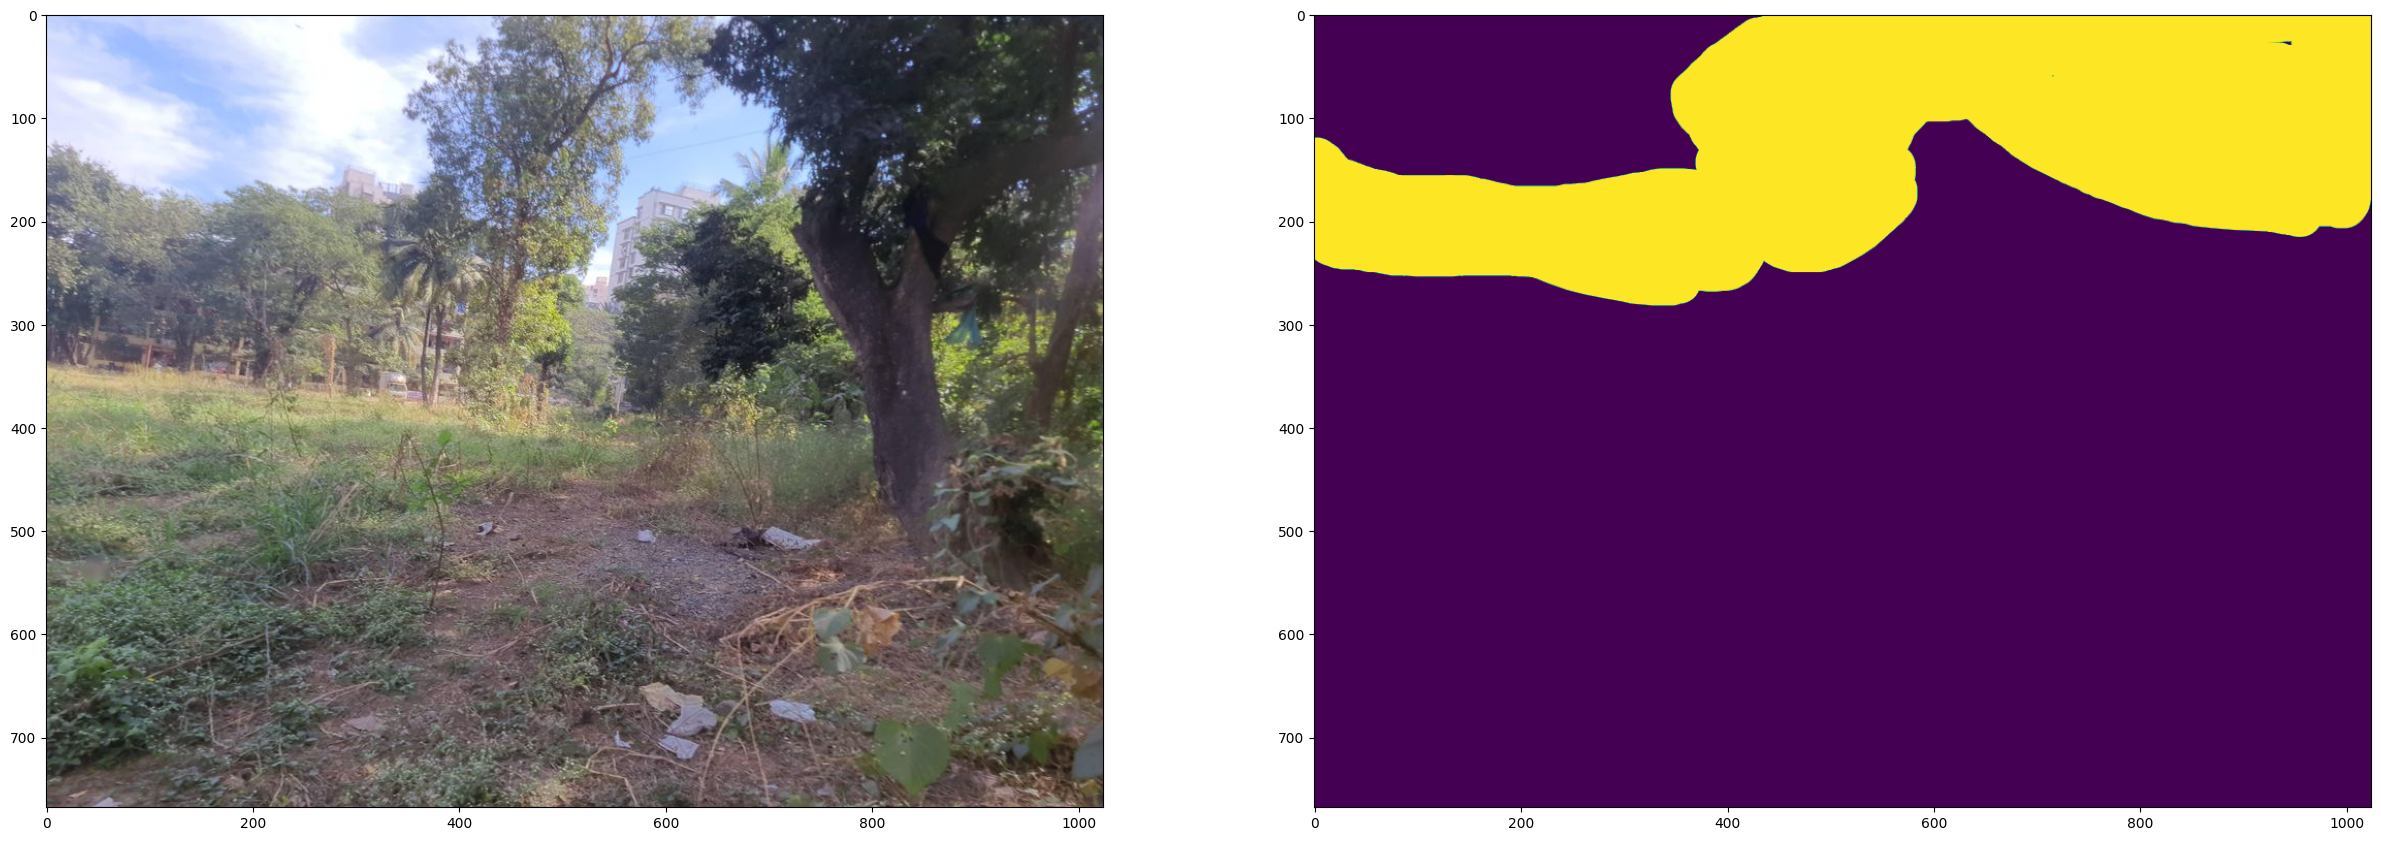

In [7]:
_, ax = plt.subplots(1, 2, figsize=(30, 20))
ax[0].imshow(img)
ax[1].imshow(res)

# LOAD RLE TO SEGFORMER MASK

In [26]:
import json

with open(
    "/Users/hariomnarang/Downloads/project-9-at-2026-02-06-11-29-481c2ec9.json"
) as f:
    content = json.load(f)

In [27]:
with_anns = [c for c in content if c["annotations"]]

In [28]:
len(with_anns)

247

In [29]:
def get_masks_for_ann(ann):
    if not ann["result"]:
        return None
    return [
        rle_to_mask(r["value"]["rle"], r["original_height"], r["original_width"])
        .astype(bool)
        .astype(np.uint8)
        for r in ann["result"]
    ]


def _img_path(lbl_std_path):
    # exmaple '/data/local-files/?d=Users/hariomnarang/Desktop/personal/roads/datasets/samples_mapillary/kandivali/images/861307543528731.jpg'}
    part = lbl_std_path.split("=")[1]
    return f"/{part}"


def extract_single_result(res):
    image = _img_path(res["data"]["image"])
    masks = []
    for ann in res["annotations"]:
        new_masks = get_masks_for_ann(ann)
        if new_masks:
            masks.extend(new_masks)

    masks = [m for m in masks if m is not None]
    img = plt.imread(image)
    full_mask = np.zeros(img.shape[:2], dtype=np.uint8)
    if masks:
        full_mask = np.logical_or.reduce(masks)
    return full_mask, image

In [34]:
mask, img_path = extract_single_result(with_anns[9])
img = plt.imread(img_path)
assert img.shape[:2] == mask.shape

print(img.shape, mask.shape)

(614, 1023, 3) (614, 1023)


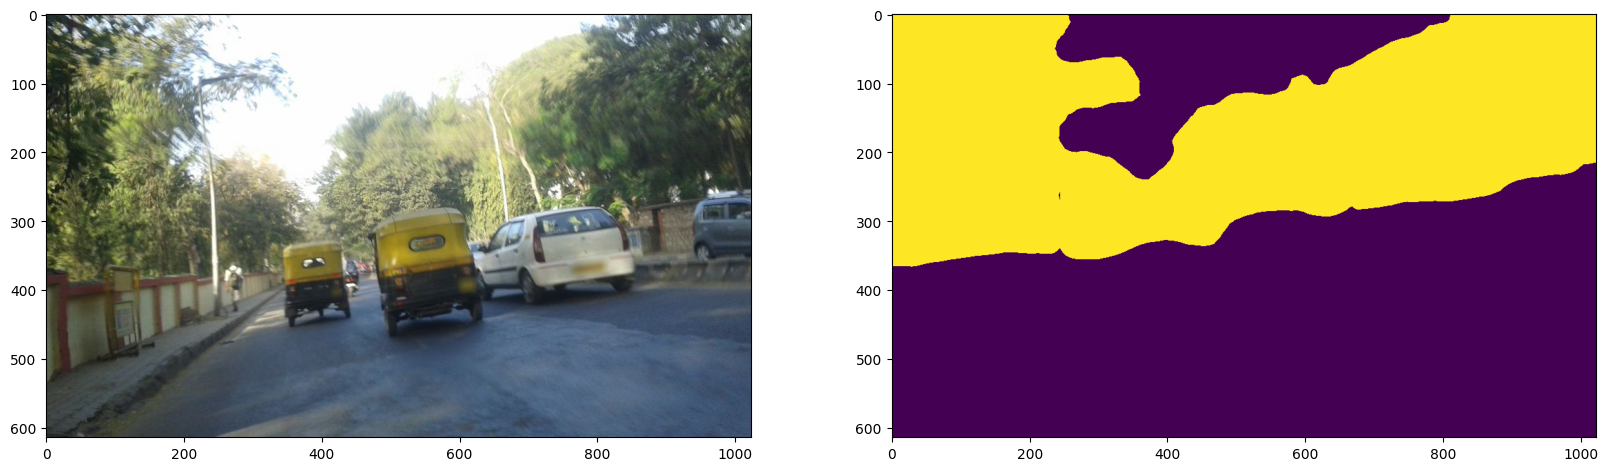

In [35]:
_, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img)
ax[1].imshow(mask)

In [36]:
OUT_DIR = Path("../../datasets/elevated-vegetation/v2_data")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [37]:
import shutil
from PIL import Image

(OUT_DIR / "masks").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "images").mkdir(parents=True, exist_ok=True)

for i, res in enumerate(with_anns):
    mask, img_path = extract_single_result(res)
    # force type cast
    mask = mask.astype(np.uint8)

    assert plt.imread(img_path).shape[:2] == mask.shape, f"shape check failed for {i}"
    uniq = sorted(np.unique(mask))
    assert uniq == [0, 1] or uniq == [0] or uniq == [1], f"unique check failed for {i}"

    fname = str(res["id"])
    pil_mask = Image.fromarray(mask, "L")
    pil_mask.save(OUT_DIR / "masks" / f"{fname}.png")
    shutil.copy(img_path, OUT_DIR / "images" / f"{fname}{Path(img_path).suffix}")


In [38]:
def single_ds(fname):
    img = OUT_DIR / "images" / f"{fname}.jpg"
    mask = OUT_DIR / "masks" / f"{fname}.png"

    image = np.array(Image.open(img).convert("RGB"))
    masks = np.array(Image.open(mask))

    _, ax = plt.subplots(1, 2)
    ax[0].imshow(image)
    ax[1].imshow(masks)

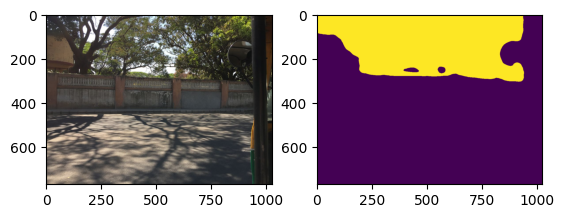

In [41]:
single_ds("18031")

In [42]:
# import torch
# from PIL import Image


# class BinarySegDataset(torch.utils.data.Dataset):
#     def __init__(self, ids, image_dir, mask_dir, processor):
#         self.ids = ids
#         self.image_dir = image_dir
#         self.mask_dir = mask_dir
#         self.processor = processor

#     def __len__(self):
#         return len(self.ids)

#     def __getitem__(self, idx):
#         id_ = self.ids[idx]

#         image = Image.open(f"{self.image_dir}/{id_}.jpg").convert("RGB")
#         mask = Image.open(f"{self.mask_dir}/{id_}.png")

#         mask = np.array(mask, dtype=np.uint8)

#         encoded = self.processor(
#             images=image, segmentation_maps=mask, return_tensors="pt"
#         )

#         # remove batch dim
#         return {
#             "pixel_values": encoded["pixel_values"].squeeze(0),
#             "labels": encoded["labels"][0],  # Mask2Former expects list-of-dicts
#         }

In [43]:
import random


def gen_train_and_val_split(image_dir):
    ids = [p.stem for p in image_dir.glob("*.jpg")]
    random.shuffle(ids)

    val_len = (2 * len(ids)) // 5
    train_len = len(ids) - val_len

    train_ids, val_ids = ids[:train_len], ids[:val_len]

    return "\n".join(train_ids), "\n".join(val_ids)

In [44]:
IMAGE_DIR = OUT_DIR / "images"
TRAIN_IDS = f"{OUT_DIR}/train.txt"
VAL_IDS = f"{OUT_DIR}/val.txt"

train_txt, val_txt = gen_train_and_val_split(IMAGE_DIR)
with open(TRAIN_IDS, "w") as f:
    f.write(train_txt)

with open(VAL_IDS, "w") as f:
    f.write(val_txt)

# Train segformer

In [3]:
import os
import torch
import numpy as np
import evaluate
from pathlib import Path

from transformers import (
    SegformerForSemanticSegmentation,
    SegformerImageProcessor,
    TrainingArguments,
    Trainer,
)

In [4]:
EXP_ROOT = Path("../../datasets/elevated-vegetation")
DS_ROOT = EXP_ROOT / "data"

OUTPUT_DIR = EXP_ROOT / "segformer-elevated-vegetation"

MASK_DIR = DS_ROOT / "masks"
IMAGE_DIR = DS_ROOT / "images"

TRAIN_IDS = f"{DS_ROOT}/train.txt"
VAL_IDS = f"{DS_ROOT}/val.txt"


MODEL_NAME = "nvidia/segformer-b0-finetuned-cityscapes-1024-1024"

In [5]:
id2label = {0: "background", 1: "elevated_vegetation"}

label2id = {"background": 0, "elevated_vegetation": 1}

NUM_LABELS = 2

In [50]:
def load_ids(path):
    with open(path, "r") as f:
        return [line.strip() for line in f if line.strip()]


train_ids = load_ids(TRAIN_IDS)
val_ids = load_ids(VAL_IDS)

In [7]:
from datasets import Dataset, DatasetDict, Image


def get_paths(image_dir, mask_dir, ids):
    image_paths = [str((image_dir / f"{i}.jpg").resolve()) for i in ids]
    mask_paths = [str((mask_dir / f"{i}.png").resolve()) for i in ids]
    return image_paths, mask_paths


def create_dataset(image_paths, label_paths):
    dataset = Dataset.from_dict(
        {"image": sorted(image_paths), "label": sorted(label_paths)}
    )
    dataset = dataset.cast_column("image", Image())
    dataset = dataset.cast_column("label", Image())
    return dataset


train_dataset = create_dataset(*get_paths(IMAGE_DIR, MASK_DIR, train_ids))
val_dataset = create_dataset(*get_paths(IMAGE_DIR, MASK_DIR, val_ids))

dataset = DatasetDict(
    {
        "train": train_dataset,
        "validation": val_dataset,
    }
)

In [8]:
metric = evaluate.load("mean_iou")

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    logits = torch.from_numpy(logits)

    # Resize logits to match label resolution
    logits = torch.nn.functional.interpolate(
        logits,
        size=labels.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

    preds = logits.argmax(dim=1).cpu().numpy()
    labels = labels

    metrics = metric.compute(
        predictions=preds,
        references=labels,
        num_labels=NUM_LABELS,
        ignore_index=None,
        reduce_labels=False
    )

    return {
        "mean_iou": metrics["mean_iou"],
        "mean_accuracy": metrics["mean_accuracy"]
    }

In [15]:
from transformers import SegformerImageProcessor

processor = SegformerImageProcessor.from_pretrained(
    MODEL_NAME,
    reduce_labels=False
)

/Users/hariomnarang/Desktop/personal/roads/mtrain/.venv/lib/python3.12/site-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


In [9]:
model = SegformerForSemanticSegmentation.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-cityscapes-1024-1024 and are newly initialized because the shapes did not match:
- decode_head.classifier.weight: found shape torch.Size([19, 256, 1, 1]) in the checkpoint and torch.Size([2, 256, 1, 1]) in the model instantiated
- decode_head.classifier.bias: found shape torch.Size([19]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [20]:
def data_collator(features):
    images = [f["image"] for f in features]
    labels = [f["label"] for f in features]

    batch = processor(
        images=images,
        segmentation_maps=labels,
        return_tensors="pt"
    )

    return batch

In [55]:
epochs = 50
lr = 0.00006
batch_size = 2

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR / "log"),
    learning_rate=lr,
    num_train_epochs=epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    save_total_limit=3,
    eval_strategy="steps",
    save_strategy="steps",
    save_steps=20,
    eval_steps=20,
    logging_steps=1,
    eval_accumulation_steps=5,
    remove_unused_columns=False,
    push_to_hub=False,
    load_best_model_at_end=True,
)

In [56]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    # compute_metrics=compute_metrics,
    data_collator=data_collator,
)

In [57]:
trainer.train()

/Users/hariomnarang/Desktop/personal/roads/mtrain/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


RuntimeError: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.